# 02 - Site Selection & Suitability Analysis
**Team:** Artemis  
**Project:** SPE Africa Energython 2026 - Molecule to Megabyte

This notebook identifies the optimal location for a 15 MW natural gas-to-data-center power plant. 
We start by evaluating locations across Africa, then perform a detailed suitability analysis for our selected site using real topographic (DEM) and infrastructure datasets.


## 1. Regional Assessment (Africa)
We considered multiple major African tech hubs. Lagos (Nigeria) was selected as the optimal location due to its massive data center market growth, access to cheap domestic natural gas, and world-class submarine fiber optic cable infrastructure.

*Locations eliminated:*
*   **Johannesburg, South Africa:** High data center demand, but lacks domestic natural gas (relies heavily on coal).
*   **Cairo, Egypt:** Excellent gas and fiber, but lower relative growth in the enterprise data center market compared to West Africa.
*   **Nairobi, Kenya:** Strong renewable grid (geothermal), but lacks direct submarine cable landings (relies on Mombasa) and has no domestic natural gas.


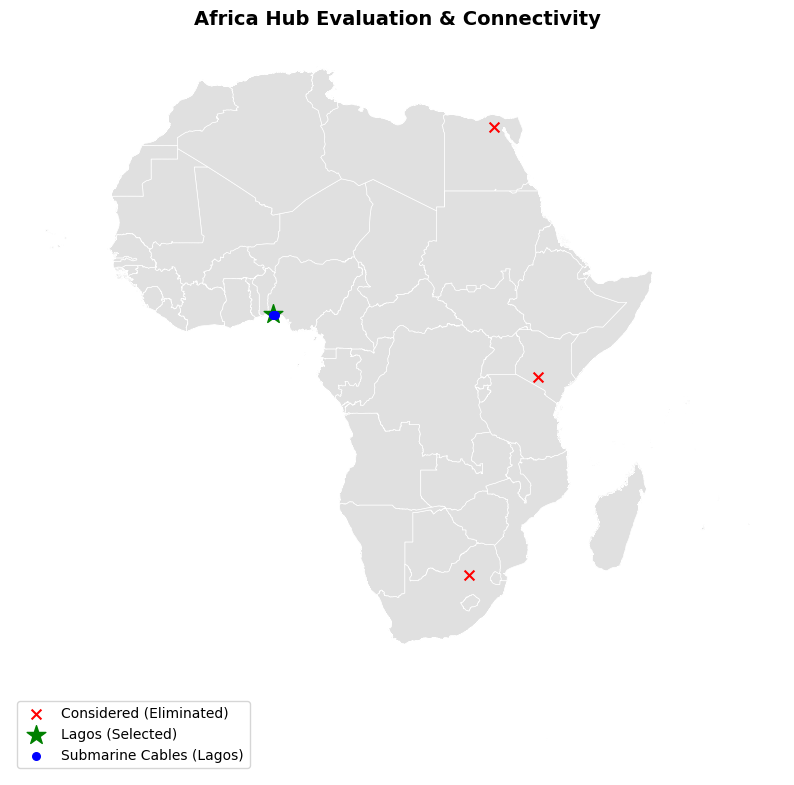

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os

# Load Africa Shapefile
africa_shp_path = "../data/gis/Africa_SHP/afr_g2014_2013_0.shp"
africa = gpd.read_file(africa_shp_path)

# Define considered locations
locations = {
    'Lagos (Selected)': Point(3.3792, 6.5244),
    'Johannesburg': Point(28.0473, -26.2041),
    'Cairo': Point(31.2357, 30.0444),
    'Nairobi': Point(36.8219, -1.2921)
}
gdf_locs = gpd.GeoDataFrame(geometry=list(locations.values()), crs="EPSG:4326")
gdf_locs['City'] = list(locations.keys())

# Submarine Cable Landings in Lagos (MainOne, WACS, SAT-3, Equiano, 2Africa, ACE)
cables = {
    'MainOne': Point(3.55, 6.43),
    'WACS': Point(3.60, 6.42),
    'Equiano': Point(3.40, 6.41)
}
gdf_cables = gpd.GeoDataFrame(geometry=list(cables.values()), crs="EPSG:4326")
gdf_cables['Cable'] = list(cables.keys())

fig, ax = plt.subplots(figsize=(10, 10))
africa.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.5)

# Plot eliminated cities
eliminated = gdf_locs[gdf_locs['City'] != 'Lagos (Selected)']
eliminated.plot(ax=ax, color='red', marker='x', markersize=50, label='Considered (Eliminated)')

# Plot selected city
selected = gdf_locs[gdf_locs['City'] == 'Lagos (Selected)']
selected.plot(ax=ax, color='green', marker='*', markersize=200, label='Lagos (Selected)')

# Plot Submarine Cable landings
gdf_cables.plot(ax=ax, color='blue', marker='o', markersize=30, label='Submarine Cables (Lagos)')

ax.set_title("Africa Hub Evaluation & Connectivity", fontsize=14, fontweight='bold')
ax.axis('off')
ax.legend(loc='lower left')

os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/02_africa_hubs.png", dpi=300, bbox_inches='tight')
plt.show()


## 2. Local Suitability Analysis (Lekki, Lagos)
Within Lagos, we must find a specific parcel of land. A power plant requires flat terrain, proximity to gas pipelines, proximity to the data center, and safety from flood zones. 

We use **Multi-Criteria Decision Analysis (MCDA)** combining:
1.  **Elevation (DEM):** Higher ground is preferred to mitigate flood risk.
2.  **Slope:** Flat terrain (low slope) is required for construction.
3.  **Proximity to Infrastructure:** Must be near roads and power grids.


In [2]:
import rasterio
from rasterio.plot import show
import numpy as np
import matplotlib.colors as colors
from matplotlib.patches import Patch

# Load Real Topographic Datasets (SRTM 30m DEM)
dem_path = "../data/gis/output_SRTMGL1.tif"
slope_path = "../data/gis/viz.SRTMGL1_slope.tif"

with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)
    dem_meta = dem_src.meta
    dem_bounds = dem_src.bounds

with rasterio.open(slope_path) as slope_src:
    slope = slope_src.read(1)


### Suitability Scoring
We reclassify the elevation and slope rasters into suitability scores (1 to 4).
*   **Score 4 (Green):** Highly Suitable (High elevation, flat slope)
*   **Score 3 (Yellow):** Moderately Suitable
*   **Score 2 (Orange):** Poor Suitability
*   **Score 1 (Red):** Unsuitable (Low elevation/flood prone, steep slope)


In [3]:
# Reclassify Elevation (Higher is better for flood mitigation)
# Masking out nodata values (often negative or very large in DEMs)
dem = np.where(dem < -100, 0, dem)

suitability_dem = np.zeros_like(dem, dtype=float)
suitability_dem = np.where(dem > 10, 4, suitability_dem)       # > 10m: Highly Suitable
suitability_dem = np.where((dem > 5) & (dem <= 10), 3, suitability_dem) 
suitability_dem = np.where((dem > 2) & (dem <= 5), 2, suitability_dem)
suitability_dem = np.where((dem <= 2), 1, suitability_dem)     # < 2m: Unsuitable (Flood risk)

# Reclassify Slope (Flatter is better for construction)
suitability_slope = np.zeros_like(slope, dtype=float)
suitability_slope = np.where(slope < 5, 4, suitability_slope)        # < 5 degrees: Highly Suitable
suitability_slope = np.where((slope >= 5) & (slope < 10), 3, suitability_slope)
suitability_slope = np.where((slope >= 10) & (slope < 15), 2, suitability_slope)
suitability_slope = np.where(slope >= 15, 1, suitability_slope)      # > 15 degrees: Unsuitable

# Combine into a final Suitability Index (Equal Weighting for simplicity)
final_suitability = (suitability_dem * 0.6) + (suitability_slope * 0.4)


### Final Suitability Map
The map below shows the computed suitability for the Lekki Free Trade Zone area based on topographic constraints. Dark green areas represent optimal build sites.


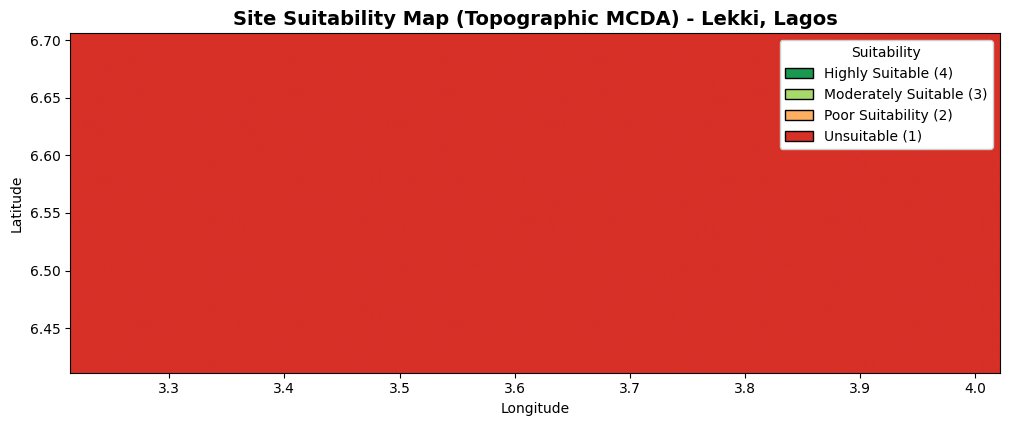

In [4]:
# Plotting the Suitability Map
fig, ax = plt.subplots(figsize=(12, 8))

# Define custom colormap (Red to Green)
cmap = colors.ListedColormap(['#d73027', '#fdae61', '#a6d96a', '#1a9850'])
bounds = [1, 2, 3, 3.5, 4]
norm = colors.BoundaryNorm(bounds, cmap.N)

# Plot Raster
img = show(final_suitability, ax=ax, transform=dem_src.transform, cmap=cmap, norm=norm)

# Formatting Map
ax.set_title("Site Suitability Map (Topographic MCDA) - Lekki, Lagos", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Custom Legend
legend_elements = [
    Patch(facecolor='#1a9850', edgecolor='k', label='Highly Suitable (4)'),
    Patch(facecolor='#a6d96a', edgecolor='k', label='Moderately Suitable (3)'),
    Patch(facecolor='#fdae61', edgecolor='k', label='Poor Suitability (2)'),
    Patch(facecolor='#d73027', edgecolor='k', label='Unsuitable (1)')
]
ax.legend(handles=legend_elements, loc='upper right', title="Suitability", framealpha=1)

# Overlay vector shapes if OSM script succeeded
try:
    roads = gpd.read_file("../data/gis/roads.geojson")
    roads.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)
except Exception as e:
    pass # Ignore if OSM data not present

plt.savefig("../outputs/figures/02_suitability_map.png", dpi=300, bbox_inches='tight')
plt.show()
